## EAS 544 Final Project - Ashton Gibson

The code below is a preliminary framework for automating the calculation of Green Gentrification Vulnerability (GGVI) using the methods from: 

Assaad, R. H., & Jezzini, Y. (2024). Green gentrification vulnerability index (GGVI): A novel approach for identifying at-risk communities and promoting environmental justice at the census-tract level. Cities, 148, 104858. https://doi.org/10.1016/j.cities.2024.104858

This was created during EAS 544/644 - Intro/Intermediate Python for Geospatial Data Science to support my team SEAS Capstone Project titled "Spatial Foundations for Green Infrastructure Knowledge in Detroit". Due to the scope of the creation timeline, this project is not complete, and **all results are preliminary/exploratory**. Specifically, Assaad and Jezzini describe 35 indicators of Green Gentrification, and my code below incorporates only 7- one from each of indicator categories. For more detailed information about how GGVI is calculated, and theoretical justification for indicator selection, refer to Assaad and Jezzini 2024. 

The code below accesses the first 5 indicators via the Census API for Python, using the 'census' python library: https://pypi.org/project/census/ and a US Census API key which I requested here: https://api.census.gov/data/key_signup.html

The next two indicator categories are based on spatial information: green stormwater infrastructure (GSI) locations and K- post-secondary school locations. 
* The GSI data was accessed via REST Endpoint URI, and downloaded as a GeoJSON, from the City of Detroit Open Data Portal: https://data-detroitmi.hub.arcgis.com/datasets/detroitmi::green-stormwater-infrastructure-locations-opendata/about
* The school point files were downloaded from the National Center for Education Statistics (nces.ed.gov), via their EDGE Open Data Portal: https://data-nces.opendata.arcgis.com/search?groupIds=455147561fd3416daa180395fb4e9237 (public schools) and https://data-nces.opendata.arcgis.com/datasets/a15e8731a17a46aabc452ea607f172c0_0/explore?location=36.275063%2C-95.702837%2C4 (post secondary)
* The Wayne county census tracts shapefile was also used to calculate spatial indicators and for plotting the final map, which I downloaded from SEMCOG Open Data: https://maps-semcog.opendata.arcgis.com/datasets/36a08f0c0dbf47a19b395be8347a35e7_59/explore?location=42.446402%2C-83.286979%2C8

The first sections of the code involve downloading and loading the various indicators into category-level dataframes. This includes the calculation of some indicators (i.e. calculating percent of population, or spatially calculating GSI per tract). Currently, each category dataframe only contains one indicator, so this will be built on in further iterations to include all indicators. 

The next section includes normalizing the data. 
The final section involves pseudocode for stastical validation testing (which could not be performed here due to not including all indicators), a function to perform Principal Component Analysis to derive weights for the GGVI calculation, and a function to calculate GGVI by tract. 

It is important to note that no data imputation was performed beyond reclassing the Census annotations of -6666666 (which means that not enough samples were collected to calculate the value) as Null values. These null values, and associated census tracts, were dropped from the data frame in order to perform PCA and are thus discluded from the final results. Future versions of this code may include an Imputation step as a part of data pre-processing, following guidelines from the OECD Handbook on Constructing Composite Indicators. 

OECD/European Union/EC-JRC (2008). Handbook on Constructing Composite Indicators: Methodology and User Guide. OECD Publishing, Paris, https://doi.org/10.1787/9789264043466-en.

Notes on Census Value Annotations: https://www.census.gov/data/developers/data-sets/acs-1year/notes-on-acs-estimate-and-annotation-values.html

More specifics about the processes are detailed below in section headings, as well as within the code as comments. 

My project uses the following Python libraries:
* geopandas (primary library for dataframe management and GeoDataFrame creation/management/spatial analysis)
* pandas
* us and states (to build API call easier)
* pathlib
* numpy
* dotenv and os (hide my API key)
* warnings (suppress )
* zipfile
* factor_analyzer (in psuedocode, eventually will allow for KMO and Bartlett's Sphericity tests for PCA suitability)
* sklearn (performing PCA and calculating eigenvalues)




Other code snippet references/sources: 
* My table join/merge code was adapted from this github tutorial: https://automating-gis-processes.github.io/2016/Lesson3-table-join.html#:~:text=Table%20joins%20are%20again%20something,4%20POINT%20(24.9214846%2060.1565781)%201005
    * Also referenced this: https://pandas.pydata.org/docs/user_guide/merging.html
* PCA example: https://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_iris.html#sphx-glr-auto-examples-decomposition-plot-pca-iris-py
* https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop_duplicates.html
* Using .apply() to create a new column based on valued from other columns, row-wise: https://stackoverflow.com/questions/26886653/create-new-column-based-on-values-from-other-columns-apply-a-function-of-multi
* Referenced the Census API User Guide: https://www2.census.gov/data/api-documentation/api-user-guide.pdf





In [1]:

import geopandas as gpd
from census import Census
from us import states
import pandas as pd
from pathlib import Path
import numpy as np

from dotenv import load_dotenv
import os

import warnings
warnings.filterwarnings("ignore")

# Load environment variables from the .env file 
load_dotenv()

# Access environment variables as if they came from the actual environment
CENSUS_API_KEY = os.getenv('CENSUS_API_KEY')

# my unique Census API Key
c = Census(CENSUS_API_KEY)

# For the current working directory
current_dir = Path.cwd()

# Data Wrangling: Accessing Data

## Grabbing Detroit Census tracts 
clipped in ArcPro and brought in as shapefile (for now)

In [2]:
# create GeoDataFrame of just Detroit census tracts
file_path = Path("data\detroit_shapefile_2024\GGVI_census_tract.shp")

# Read in census tracts shapefile as GeoDataframe
dt_tracts_df = gpd.read_file(current_dir / file_path)
# removing unnecessary (to me) columns
detroit_gdf = dt_tracts_df.iloc[:,20:]

# Reproject census tracts GeoDataframe to NAD83 Michigan South (feet)
detroit_gdf = detroit_gdf.to_crs(2898)

## Indicator Groups 1-5
the code below is defining the census ACS tables specified. I have chosen one table/indicator to represent each category, creating a foundation for additional tables/indicators to be included.
ACS 5-year Data source/reference: https://api.census.gov/data/2023/acs.html

In [3]:
# this was necessary for an earlier version of the code, to do all the indicator groups as one dataframe.
all_tables = ['B17001_001E', 'B05001_001E', 'B05001_006E', 'B25064_001E', 'B19013_001E', 'B02001_001E', 'B02001_002E'] 

# the dictionary below can be used to rename ACS table columns to more descriptive names; kept here just as a reference of the data I'm using and how they relate to the overall calculation
tables_names = {'B17001_001E':'Poverty Status in the Past 12 Months',                                                # indicator group 1: Economic factors
                'B05001_001E':'universe of US Citizens',                                                             # indicator group 2: Social factors. 
                'B05001_006E':'Estimate!!Total:!!Not a U.S. citizen',                                                    # (006E / 001E = percent of non-US citizens)
                'B25064_001E':'Median Gross rent',                                                                   # indicator group 3: Housing factors
                'B19013_001E':'Median Household Income in the Past 12 Months (in 2024 Inflation-Adjusted Dollars)',  # indicator group 4: Household factors
                'B02001_001E':'universe of Race: Estimate!!Total:',                                                  # Indicator group 5: Demographic factors
                'B02001_002E':'Estimate!!Total:!!White alone'                                                            # (002E/001E = percent of population that is white alone)
                }





## Indicator Group 1: Economic
### Specific Indicator selected (based on Assaad and Jezzini 2024): Poverty

Here, I used ACS table B17001_001E: Poverty Status in the Past 12 Months (number of people)

In [4]:
# add additional acs table codes here 
acs_economic = ['B17001_001E'] 

# Building the API call for the data; 163 is the county code for Wayne county
economic_tables = c.acs5.get(
    acs_economic, 
    geo={'for': 'tract:*', 'in': 'state:{} county:163'.format(states.MI.fips)}
) 

# converting to dataframe to do additional transformations
economic_tables = pd.DataFrame(economic_tables) 

# sometimes, census data has -666666.00 instead of null; reclassing all those to null using numpy NaN. 
# Justification: it skews the normalization, but it shouldn't be zero, which would also skew the norm
economic_tables[acs_economic] = economic_tables[acs_economic].replace(-666666666.0, np.nan) 

# renaming the column for easy recognition (optional since the acs table code is more traceable)
economic_tables = economic_tables.rename(columns={'B17001_001E': 'poverty_status'}) 


<Axes: >

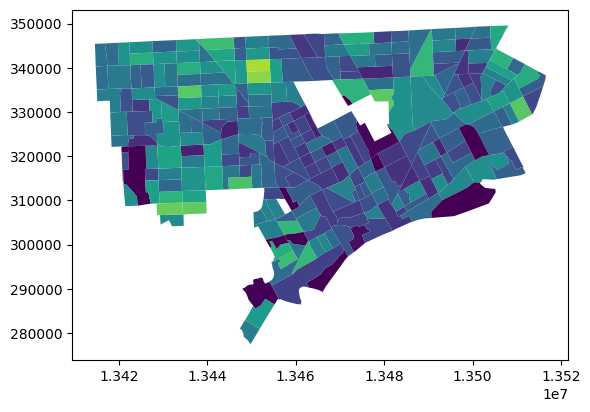

In [5]:
# filter ACS economic data to just detroit census tracts by joining census data to tracts
economic_tables = detroit_gdf.merge(
    economic_tables, left_on='TRACTCE', 
    right_on='tract', 
    how='left') 

economic_tables.plot(column = 'poverty_status')

## Indicator Group 2: Social
### Specific Indicator selected: Citizenship Status

Here, i used ACS tables 'B05001_001E':'universe of US Citizens', and 'B05001_006E':'Estimate!!Total:!!Not a U.S. citizen'. The actual indicator is percent of non-us citizens, so the code below adds a new column to the Social Factors dataframe called 'pct_non_US'. The values for this column are derived by dividing the 006E table by the 001E table for each row (tract). The output is a proportion, between 0-1. It can be made into a percentage by multiplying by 100% if needed.

In [6]:
# add additional acs table codes here
acs_social = ['B05001_001E','B05001_006E'] 

# Building the API call for the data; 
social_tables = c.acs5.get(
    acs_social,
    geo={'for': 'tract:*', 'in': 'state:{} county:163'.format(states.MI.fips)}
)

#converting to dataframe to do additional transformations
social_tables = pd.DataFrame(social_tables) 

# for Indicator Group 2, final value is column 2 divided by column 1; 
# so must create new column that equals 006E/001E
# also must handle if 001E == 0, to output 0 instead of an error

# initialize column to 0, below will change if 001E does NOT equal 0, otherwise no change (stays 0.0)
social_tables['pct_non_US'] = 0.0 

 # only changing the value of 'pct_non_US' column where the denominator (001E) is not 0, preventing divide by zero error. 
 # 'pct_non-US' column is populated with the value of 006E/001E (which will be between 0-1)
social_tables['pct_non_US'] = np.where(      
    social_tables['B05001_001E'] != 0,
    social_tables['B05001_006E']/ social_tables['B05001_001E'], 
    0
)


<Axes: >

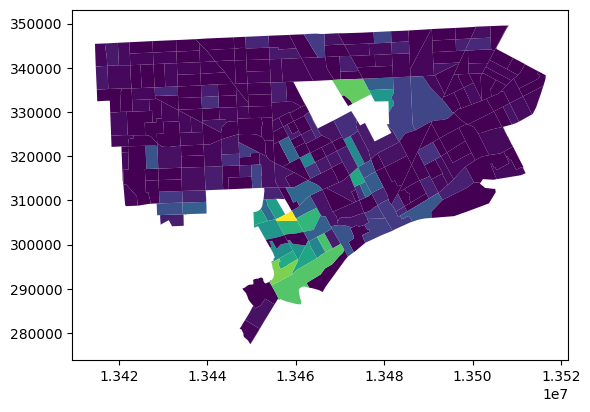

In [7]:
# filter ACS social data to just detroit census tracts by joining census data to tracts
social_tables = detroit_gdf.merge(social_tables, left_on='TRACTCE', right_on='tract', how='left') # Join census output dataframe to shapefile dataframe
social_tables.plot(column = 'pct_non_US')

## Indicator Group 3: Housing
### Specific Indicator selected: Gross Rent

Here I used ACS table 'B25064_001E':'Median Gross rent' by tract

In [8]:
# add additional acs table codes here
acs_housing = ['B25064_001E'] 

housing_tables = c.acs5.get(
    acs_housing, 
    geo={'for': 'tract:*', 'in': 'state:{} county:163'.format(states.MI.fips)}
)

# converting to dataframe to do additional transformations
housing_tables = pd.DataFrame(housing_tables) 

# sometimes, census data has -666666.00 instead of null; reclassing all those to null using numpy NaN. 
# Justification: it skews the normalization, but it shouldn't be zero, which would also skew the norm
housing_tables[acs_housing] = housing_tables[acs_housing].replace(-666666666.0, np.nan) 

 # renaming the column for easy recognition (optional since the acs table code is more traceable)
housing_tables = housing_tables.rename(columns={'B25064_001E': 'med_gross_rent'})


<Axes: >

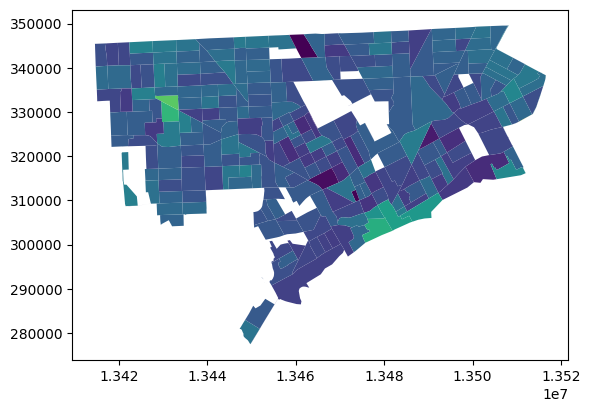

In [9]:
# filter ACS housing data to just detroit census tracts by joining census data to tracts
housing_tables = detroit_gdf.merge(
    housing_tables, 
    left_on='TRACTCE', 
    right_on='tract', 
    how='left'
) 

housing_tables.plot(column = 'med_gross_rent')

## Indicator Group 4: Household
### Specific Indicator selected: Household Income

Here I used ACS table 'B19013_001E':'Median Household Income in the Past 12 Months (in 2024 Inflation-Adjusted Dollars)'

In [10]:
# add additional acs table codes here
acs_household = ['B19013_001E'] 

household_tables = c.acs5.get(
    acs_household, 
    geo={'for': 'tract:*', 'in': 'state:{} county:163'.format(states.MI.fips)}
)

household_tables = pd.DataFrame(household_tables) 

household_tables[acs_household] = household_tables[acs_household].replace(-666666666.0, np.nan) 

household_tables = household_tables.rename(columns={'B19013_001E': 'med_household_income'})


<Axes: >

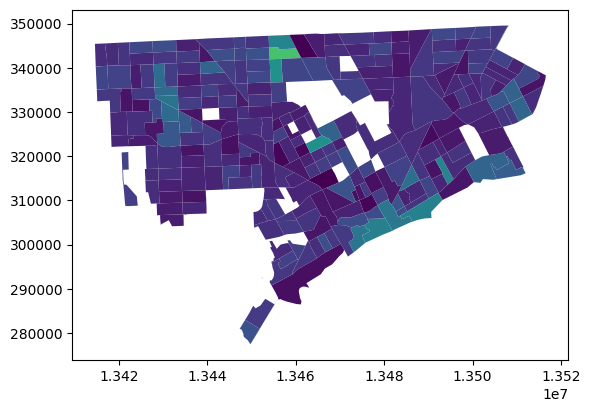

In [11]:
# filter ACS household data to just detroit census tracts by joining census data to tracts
household_tables = detroit_gdf.merge(
    household_tables, 
    left_on='TRACTCE', 
    right_on='tract', 
    how='left') 

household_tables.plot(column = 'med_household_income')

## Indicator Group 5: Demographic
### Specific Indicator selected: Race and Ethnicity

For demographic, I used ACS Tables 'B02001_001E':'universe of Race: Estimate!!Total:' and 'B02001_002E':'Estimate!!Total:!!White alone'. The indicator according to Assaad and Jezzini is percent of the population that is white alone, so the process used for Indicator group 2 was repeated: I created a new column in the dataframe called 'pct_white_alone', which is calculated as the value of column 002E divided by the value of column 001E, except where 001E is 0, which will be left as zero as to avoid a 'divide by zero' error. 

In [12]:
# add additional acs table codes here
acs_demographic = ['B02001_001E','B02001_002E'] 

demographic_tables = c.acs5.get(
    acs_demographic, 
    geo={'for': 'tract:*', 'in': 'state:{} county:163'.format(states.MI.fips)}
)

demographic_tables = pd.DataFrame(demographic_tables) 

# for Indicator Group 2, final indicator value is column 2 divided by column 1; so must create new column that equals 002E/001E
# also must handle if 001E == 0, to output 0 instead of an error

# initialize column to 0, below will change if 001E does NOT equal 0, otherwise no change (stays 0.0)
demographic_tables['pct_white_alone'] = 0.0 

# only changing the value of 'pct_white_alone' column where the denominator (001E) is not 0, preventing divide by zero error. 
# 'pct_white_alone' column is populated with the value of 002E/001E (which will be between 0-1)
demographic_tables['pct_white_alone'] = np.where( 
    demographic_tables['B02001_001E'] != 0,
    demographic_tables['B02001_002E']/ demographic_tables['B02001_001E'], 
    0
)


<Axes: >

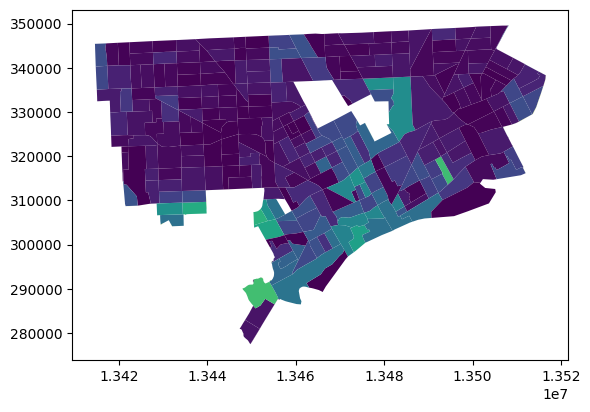

In [13]:
# filter ACS demographic data to just detroit census tracts by joining census data to tracts
demographic_tables = detroit_gdf.merge(demographic_tables, left_on='TRACTCE', right_on='tract', how='left') # Join census output dataframe to shapefile dataframe
demographic_tables.plot(column = 'pct_white_alone')

## Indicator Group 7: Green Infrastructure (GIs)
### Specific Indicator Selected: GIs Frequency 
this is defined by Assaad and Jezzini as the number of green infrastructure projects per census tract. In my analysis below, I used only a dataset of Green *Stormwater* infrastructure projects, from the City of Detroit Open Data Portal. Thus, this indicator as-is represents Green Stormwater Infrastructure freqeuncy per census tract.

<Axes: >

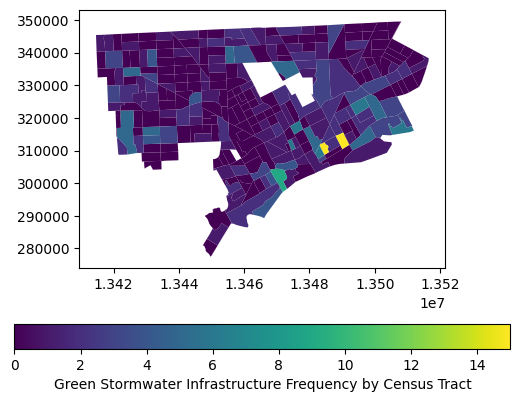

In [14]:
# Reproject census tracts GeoDataframe to NAD83 Michigan South (feet)
GSI_gdf = detroit_gdf.to_crs(2898)

# Reading in GSI locations via REST endpoint from Detroit Open Data Hub, reproject to NAD83
GSI_points = gpd.read_file("https://services2.arcgis.com/qvkbeam7Wirps6zC/arcgis/rest/services/Green_Stormwater_Infrastructure_Locations_OpenDataPortal/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson")
GSI_points = GSI_points.to_crs(2898)

# left-hand spatial join: assigning attributes of census tracts (mainly ID) to each point
join_left_df = GSI_points.sjoin(GSI_gdf, how="left")

# this creates an array with the tract IDs and the count of points in each one (min of 1)
counts = join_left_df.groupby('TRACTCE').size().rename('GSI_count') 

# merging point counts with the original shapefile geometry, left-hand join to keep all tracts
GSI_by_tract = GSI_gdf.merge(counts, left_on='TRACTCE', right_on='TRACTCE', how='left') 

# some tracts have no points, so changing NULL vals in point_count to 0
GSI_by_tract['GSI_count'] = GSI_by_tract['GSI_count'].fillna(0).astype(int) 

# plot map of tracts by count, to verify
GSI_by_tract.plot(column= 'GSI_count', legend = True, legend_kwds={"label": "Green Stormwater Infrastructure Frequency by Census Tract", "orientation": "horizontal"}) 


## Indicator Group 6: Amenities
### Specific Indicator selected: Proximity to schools

this is defined by Assaad and Jezzini as the distance from the centroid of the census tract to the nearest school point. They only include high school and post-secondary schools, while my code below uses public K-12 and all post-secondary schools in Wayne County. I downloaded the shapefiles for public K-12 schools and post-secondary schools from the National Center for Education Statistics (NCES). Then, I filtered by location and merged them into a single dataset.

<Axes: >

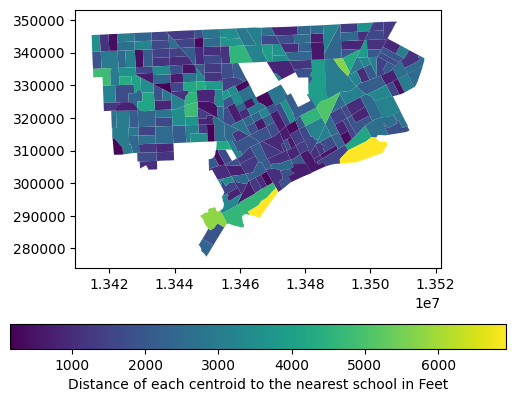

In [15]:

import zipfile

# Eventually want to use these URLs to grab zip files instead of using local downloads; having issues finding a non-complicated way to do that
#public_school_pts = "https://nces.ed.gov/programs/edge/data/EDGE_GEOCODE_PUBLICSCH_2425.zip"
#secondary_school_pts = "https://nces.ed.gov/programs/edge/data/EDGE_GEOCODE_POSTSECSCH_2425.zip"

destination1 = "data\outputs\schools\public_schools"
destination2 = "data\outputs\schools\secondary_schools"

public_school_pts = "EDGE_GEOCODE_PUBLICSCH_2425.zip"
secondary_school_pts = "EDGE_GEOCODE_POSTSECSCH_2425.zip"

# first, unzipping this data folder. Another zipfile is contained which also needs to be unzipped
with zipfile.ZipFile(public_school_pts, 'r') as zip_ref:
    zip_ref.extractall(destination1)

with zipfile.ZipFile("data\outputs\schools\public_schools\Shapefile_SCH.zip", 'r') as zip_ref:
    zip_ref.extractall(destination1)

# Second, unzipping Post Secondary schools locations (college/university)
with zipfile.ZipFile(secondary_school_pts, 'r') as zip_ref:
    zip_ref.extractall(destination2)

with zipfile.ZipFile("data\outputs\schools\secondary_schools\SHAPEFILE.zip", 'r') as zip_ref:
    zip_ref.extractall(destination2)

# Next, convert shapefiles to GDF to take a look at data schema. I want to filter schools down to State = MI and County = Wayne, then append one list onto the other
public_sch_file_path = Path("data\outputs\schools\public_schools\EDGE_GEOCODE_PUBLICSCH_2425.shp")
secondary_sch_file_path = Path("data\outputs\schools\secondary_schools\SHAPEFILE\EDGE_GEOCODE_POSTSECSCH_2425.shp")
pub_sch_gdf = gpd.read_file(current_dir / public_sch_file_path)
sec_sch_gdf = gpd.read_file(current_dir / secondary_sch_file_path)

# filtering
pub_sch_gdf = pub_sch_gdf[(pub_sch_gdf['STATE']== 'MI') & (pub_sch_gdf['NMCNTY'] == 'Wayne County')]

sec_sch_gdf = sec_sch_gdf[(sec_sch_gdf['STATE']== 'MI') & (sec_sch_gdf['NMCNTY'] == 'Wayne County')]


# appending filtered post secondary schools onto the public school list, to get list of all school locations in Wayne Co, MI
# NOTE: schools used in Assaad and Jezzini 2024 only includes high schools and post-secondary as gentrification indicators. 
# My all_schools layer below contains all public schools, K through college, thus will need t be fixed for future versions
all_schools = pd.concat([pub_sch_gdf,sec_sch_gdf], ignore_index= True)
all_schools = all_schools.to_crs(2898)


# calculate centroid of the wayne county census tract polygons
detroit_gdf = detroit_gdf.to_crs(2898)
centroid_gdf = detroit_gdf.copy()
centroid_gdf.geometry = detroit_gdf.centroid

# Check centroid points by plotting census tracts with centroid points on top
#base = detroit_gdf.plot(color='white', edgecolor='black')
#centroid_gdf.plot(ax=base, marker='o', color='red', markersize=5);
#print(centroid_gdf)

# calculating the distance of each census tract centroid to the Nearest school point
# left hand spatial join to preserve the census centroid point data (particularly the census tract ID)
school_dist = centroid_gdf.sjoin_nearest(
    all_schools, 
    distance_col= "dist_school_ft", 
    how= "left"
)

# school_dist now contains a point layer with a column titled "dist_school_ft" which is the distance from the centroid to the nearest school point in feet
#print(school_dist)

# next, I want to take the column containing the distances, and stick it back onto the census geometry 
# (this is just for visualization, as long as each distance still has a census tract ID, it can be used in the final calculations)
tracts_school_dist = detroit_gdf.merge(
    school_dist[['TRACTCE', 'dist_school_ft']], 
    on='TRACTCE', 
    how='left'
)

# plotting tracts by distance to nearest school
tracts_school_dist.plot(
    column= 'dist_school_ft', 
    legend = True, 
    legend_kwds={"label": "Distance of each centroid to the nearest school in Feet", 
                 "orientation": "horizontal"}
)

# if geometry isn't needed at this step, just use school_dist, which has the census tract ID ('TRACTCE') and the distance of the centroid to the nearest school ('dist_school_ft'). 
# the column 'dist_school_ft' is the raw value of the indicator.

# Data Preprocessing: Min-Max Normalization
From Assaad and Jezzini 2024: "the Min-Max technique was used to scale the data into a unitless and comparable scale"
**Equation: Zi= (Xi - Xmin)/(Xmax - Xmin)**, "where Zi, Xi, Xmin, and Xmax represent the scaled value, the original value, the minimum of the original value, and the maximum of the original value, respectively."

HOWEVER, indicators which have an *inverse* relationship to green gentrification are scaled using an Inverse Min-Max, as follows:
**Equation: Zi= 1 - ((Xi - Xmin)/(Xmax - Xmin))**

#### ACS Derived Indicators
* Poverty: **positive relationship**; more people in poverty means more risk of green gentrification (GG)
* Citizenship Status: **positive**: higher proportion of non-US citizens means more risk of GG
* Gross rent: **inverse relationship**; higher median gross rent means less vulnerability to GG
* Household Income: **inverse relationship**; higher household income means less vulnerability to GG
* Race and ethnicity: **inverse**; higher proportion of white-alone people means less vulnerability to GG

#### Spatial Indicators
* Proximity to schools: **inverse**; as distance to schools increases, vulnerability to GG decreases (areas near schools, i.e. lower distance, are more likely to be gentrified)
* GSI frequency: **positive**; tracts with more GSI infrastructure projects are more vulnerable to GG


### Positive Min-Max
#### Note: min-max normalization is performed below for indicators Citizenship Status and Race and Ethnicity, which are already proportions (percents of total tract population). This could introduce bias towards outliers, so methodology should be double-checked/made explicit in future implementations

***Also note:*** in the code above that prepares the columns in each table, I have reclassified the -666666.0 values in the census ACS data (particularly relevant for median rent and median household income) to be NaN (aka null values). Originally I reclassed them to 0, but this messes up the normalization below. So, below, all rows which have NaN for the census table value, will have NaN added to the normalized value column, so that they aren't considered in the min-max, but not fully deleted from the dataset.

In [16]:
# Poverty: economic_tables, column 'poverty_status'
economic_tables['norm_poverty'] = 0.0 # min-max normalized column is named norm_poverty

# where column is not NaN, calculate the min-max normalized value, else assign norm_poverty to NaN
economic_tables['norm_poverty'] = np.where( 
    economic_tables['poverty_status'].notnull(),
    (economic_tables['poverty_status'] - economic_tables['poverty_status'].min())/(economic_tables['poverty_status'].max() - economic_tables['poverty_status'].min()),
    np.nan
)

# Citizenship Status: social_tables, column 'pct_non_US'
social_tables['norm_non_US'] = 0.0 # min-max normalized column is named norm_non_US

# where column is not NaN, calculate the min-max normalized value, else assign norm_non_us to NaN
social_tables['norm_non_US'] = np.where( 
    social_tables['pct_non_US'].notnull(),
    (social_tables['pct_non_US'] - social_tables['pct_non_US'].min())/(social_tables['pct_non_US'].max() - social_tables['pct_non_US'].min()),
    np.nan
)

# GSI frequency: GSI_by_tract, column 'GSI_count'
GSI_by_tract['norm_GSI_count'] = 0.0
GSI_by_tract['norm_GSI_count'] = (GSI_by_tract['GSI_count'] - GSI_by_tract['GSI_count'].min())/(GSI_by_tract['GSI_count'].max() - GSI_by_tract['GSI_count'].min())


### Inverse Min-Max

In [ ]:
# Gross Rent: housing_tables, column 'med_gross_rent'
housing_tables['norm_gross_rent'] = 0.0

# where column is not NaN, calculate the min-max normalized value, else assign norm_gross_rent to NaN
housing_tables['norm_gross_rent'] = np.where( 
    housing_tables['med_gross_rent'].notnull(),
    1-((housing_tables['med_gross_rent'] - housing_tables['med_gross_rent'].min())/
       (housing_tables['med_gross_rent'].max() - housing_tables['med_gross_rent'].min())),
    np.nan
)

# Household Income: household_tables, column 'med_household_income'
household_tables['norm_household_income'] = 0.0

# where column is not NaN, calculate the min-max normalized value, else assign norm_household_income to NaN
household_tables['norm_household_income'] = np.where( 
    household_tables['med_household_income'].notnull(),
    1-((household_tables['med_household_income'] - household_tables['med_household_income'].min())/(household_tables['med_household_income'].max() - household_tables['med_household_income'].min())),
    np.nan
)

# Race and ethnicity: demographic_tables, column 'pct_white_alone'
# NOTE normalizing a proportion... can comment out code below or set 'norm_white_alone' = 'pct_white_alone' to not re-normalize the distribution
demographic_tables['norm_white_alone'] = 0.0

# where column is not NaN, calculate the min-max normalized value, else assign norm_white_alone to NaN
demographic_tables['norm_white_alone'] = np.where( 
    demographic_tables['pct_white_alone'].notnull(),
    1-((demographic_tables['pct_white_alone'] - demographic_tables['pct_white_alone'].min())/(demographic_tables['pct_white_alone'].max() - demographic_tables['pct_white_alone'].min())),
    np.nan
)

# Proximity to schools: school_dist, column 'dist_school_ft'
school_dist['norm_sch_dist_ft'] = 0.0
school_dist['norm_sch_dist_ft'] = 1-((school_dist['dist_school_ft'] - school_dist['dist_school_ft'].min())/(school_dist['dist_school_ft'].max() - school_dist['dist_school_ft'].min()))




# Data Preprocessing: checking suitability of data for Principle Component Analysis
#### In order to verify that performing PCA would give valid results, the data must pass the KMO test of sampling adequacy as well as the Bartlett's sphericity test. PCA will be applied to each of the seven categories. Thus, I believe that these suitability tests will be done per category, to determine reduncancy of indicator variables within each indicator category. According to Assaad and Jezzini 2024, the data is considered suitable for PCA when the KMO test value is greater than 0.5, and the Bartlett's p-value is significant at less than or equal to 0.05. 

I will use the factor_analyser library for python, importing calculate_kmo and calculate_bartlett_sphericity. Code sources/library help for this section is from: https://www.datacamp.com/tutorial/introduction-factor-analysis

**Some Considerations:**
* for the purposes of this project, I have only selected one indicator from each of the seven categories, meaning these tests (and category-level PCA) will not be possible
* KMO and Bartlett tests cannot handle NaN values, so this will need to be considered for the final dataset. 

In [18]:
# below is pseudocode that could be developed to perform the category-level validity tests

#from factor_analyzer.factor_analyzer import calculate_kmo
#from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

# the tests may only consider numeric data, so I will create copy dataframes that containn only the normalized indicator values. 
# I will also .dropna() to remove NaN from the copy df's
# these new dataframes will be named df1-7, for each of the 7 categories defined above
# the outputs of the test will also be labeled with numbers correlating to their category number, 
# i.e. for group 1, Economic factors: df1, kmo_all_1, kmo_model_1, chi_1, p_1
# I can add all of the variables to a final table with columns for the test output vars, where each row corresponds to the category group number
validity_results = pd.DataFrame(columns=['group','kmo_all','kmo_model','bs_chi_square','bs_p_value'])

# Indicator Group 1: Economic Factors

# this creates a copy of the economic tables dataframe, but only keeps columns whose names begin with "norm_" 
# (so getting rid of the raw data and the census/state/county). 
# Requires that normalized columns all use the same naming convention!!!
df1 = economic_tables.filter(regex='^norm_').copy().dropna() 


# following rows are commented out in order to keep code running

#kmo_all_1, kmo_model_1 = calculate_kmo(df1) # Group 1 KMO test (all means the KMO when using all values, model means KMO for subset of vars which are suitable)
#chi_1, p_1 = calculate_bartlett_sphericity(df1) # Group 1 Bartlett test
#validity_results.loc[0] = [1,kmo_all_1,kmo_model_1,chi_1,p_1] # add test data to the first row of the validity test results table

# NOTE: Repeat with next 6 groups, following naming convention

# Indicator Group 2: Social Factors
df2 = social_tables.filter(regex='^norm_').copy().dropna() # this creates a copy of the economic tables dataframe, but only keeps columns whose names begin with "norm_" (so getting rid of the raw data and the census/state/county). Requires that normalized columns all use the same naming convention!!!
#kmo_all_2, kmo_model_2 = calculate_kmo(df2) # Group 2 KMO test (all means the KMO when using all values, model means KMO for subset of vars which are suitable)
#chi_2, p_2 = calculate_bartlett_sphericity(df1) # Group 2 Bartlett test
#validity_results.loc[1] = [2,kmo_all_1,kmo_model_1,chi_1,p_1] # add test data to the second row of the validity test results table

# etc. repeat for all 7 indicator categories
# can only run once at least two indicator columns are added to each categories' dataframe


after this, verify that validity_results table has valid results. kmo_model should be >0.5 and bs_p_value should be less than/equal to 0.05

# Calculating Weights with PCA 

To aid in calculating eigenvalues and variance, I'll  use the scikitlearn decomposition module; documentation here: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

From Assaad and Jezzini 2024:
"To weigh the green gentrification indicators, PCA was applied separately to each of the 7 categories of green gentrification indicators (see Fig. 1). Then the weight of each indicator with respect to its category was calculated based on Eqs. (3), (4), (5)."

Eqn (3): P_ijk = ((p_ijk)^2)/L_jk
* i is indicator in category k; j is the principle component
* P_ijk is the ratio of the variance in the data explained by each indicator within its category, compared to the variance explained by the principle component alone
* p_ijk is the factor loading of indicator i in principle component j
* L_jk is the eigenvalue of principle component j (and is calculated as the sum of (p_ijk)^2 for all indicators in one category) 

Eqn (4): phi_jk = L_jk / sum(L_jk)
* phi_jk is the ratio of variance explained by j to the sum of variance explained by all principle components in category k

Eqn (5): w_ik = sum(phi_jk * P_ijk) 
* w_ik is the weight of indicator i within category k; sum of phi_jk * P_ijk for all principle components 


## Calculating vulnerability score for each category

Eqn (6): V_k = sum( w_ik * Z_ik)
* V_k is the vulnerability score of the census tract of category k
* w_ik is the weight of indicator i in category k
* Z_ik is the normalized indicator value (in the norm_[category] columns)
* the sum is adding the weight times the indicator value for all indicators in the catgory


## PCA Function to calculate eqns (3),(4), and (5)

PCA is performed in two different steps: 
* first, to calculate the weight of each indicator with respect to its category. PCA would thus be called on each of the seven category data frames individually.
* second, to calculate the weight of each cateogry with respect to overall GGVI

In the code below, I skip the first calculation , sicne you can't run PCA on a dataframe with only one column (indicator). So, I treat the data as the input for PCA #2: essentially treating Z (the normalized indicator value) as V (the category level vulnerability score for the tract)


In [19]:
import numpy as np
from sklearn.decomposition import PCA
 
 

def compute_indicator_weights(data: np.ndarray):
    """
    Given normalised indicator data for ONE category, return the PCA-derived
    weight for every indicator.  
    
    OR

    Given the category score by tract for all 7 categories, return PCA-derived 
    weight for every category.

    Weights sum to 1.
 
    Parameters:
    data : array of shape (n_census_tracts, n_indicators)
 
    Returns:
    weights : array of shape (n_indicators,)
    pca     : fitted PCA object
    """
    n_tracts, n_indicators = data.shape
 
    
    # STEP 1: Run PCA  
    pca = PCA(n_components=n_indicators)
    pca.fit(data)
 
    eigenvalues = pca.explained_variance_            # one per component
    variance_pct = pca.explained_variance_ratio_     # fraction of total variance
 
   
    # STEP 2: Decide which components to keep
    #   Based on Assaad and Jezzini 2024, components must have these features to be kept:
    #      1. eigenvalue > 1
    #      2. explains ≥ 10 % of variance on its own
    #      3. stop once cumulative explained variance exceeds 60 %
  
    kept_components = []
    cumulative_variance = 0.0
 
    for j in range(len(eigenvalues)):
        big_enough    = eigenvalues[j] > 1
        explains_10   = variance_pct[j] >= 0.10
 
        if big_enough and explains_10:
            kept_components.append(j)
            cumulative_variance += variance_pct[j]
            if cumulative_variance > 0.60:
                break
 
    # always keep at least the first component
    if not kept_components:
        kept_components = [0]
 

    # STEP 3: Compute factor loadings for the kept components
    
    #   A "factor loading" tells you how strongly each indicator
    #   correlates with a given principal component.

    #   sklearn stores eigenvectors in pca.components_ (one row per PC).
    
    all_loadings = np.zeros_like(pca.components_)
    for j in range(len(eigenvalues)):
        for i in range(n_indicators):
            all_loadings[j, i] = pca.components_[j, i] * np.sqrt(eigenvalues[j])
 
    
    # STEP 4: Equation (3)  "How much of component j's variance
    #           does indicator i explain?"
    
    #   rho_ij = loading_ij^2 / eigenvalue_j
    
    #   Squaring the loading gives the variance contributed by that
    #   indicator to that component.  Dividing by the eigenvalue
    #   (= total variance of the component) turns it into a fraction.
    #   All rho_bar values for one component sum to 1.
   
    rho_bar = {}  # keyed by (component_index, indicator_index)
 
    for j in kept_components:
        for i in range(n_indicators):
            loading = all_loadings[j, i]
            rho_bar[(j, i)] = (loading ** 2) / eigenvalues[j]
 
    
    # STEP 5: Equation (4)  "How important is component j compared
    #           to the other kept components?"
    
    #   phi_j = eigenvalue_j / (sum of eigenvalues of all kept components)
    
    #   This gives each kept component a share that sums to 1.
    
    total_eigenvalue_kept = sum(eigenvalues[j] for j in kept_components)
 
    phi = {}  # keyed by component_index
    for j in kept_components:
        phi[j] = eigenvalues[j] / total_eigenvalue_kept
 
    
    # STEP 6: Equation (5)  "Final weight for each indicator"
    
    #   ω_i = SUM_j  (phi_j × rho_bar_ij)
    
    #   For every indicator, walk through the kept components and
    #   accumulate:  (component importance) × (indicator's share in
    #   that component).  The result across all indicators sums to 1.
    
    weights = np.zeros(n_indicators)
 
    for i in range(n_indicators):
        for j in kept_components:
            component_importance   = phi[j]
            indicator_share_in_j   = rho_bar[(j, i)]
            weights[i] += component_importance * indicator_share_in_j
 
    return weights, pca


## 

The code below is really messy, and will be more concise via a for loop in future iterations :)

In [20]:
# data management: somehow, the TRACTCE, which is the unique census tract ID number, is a string.
# thus, convert it to an integer! 
economic_tables["TRACTCE"]        = economic_tables["TRACTCE"].astype(int)
social_tables["TRACTCE"]          = social_tables["TRACTCE"].astype(int)
GSI_by_tract["TRACTCE"]       = GSI_by_tract["TRACTCE"].astype(int)
housing_tables["TRACTCE"]         = housing_tables["TRACTCE"].astype(int)
household_tables["TRACTCE"]       = household_tables["TRACTCE"].astype(int)
demographic_tables["TRACTCE"]     = demographic_tables["TRACTCE"].astype(int)
school_dist["TRACTCE"]        = school_dist["TRACTCE"].astype(int)

# indexing all catogory dataframes by census tract ID number, filtering columns
# now only columns whose names start with "norm_" are added, grabbing all normalized indicator values
economic_tables_1 = economic_tables.set_index("TRACTCE").filter(regex='^norm_').copy()
social_tables_1 = social_tables.set_index("TRACTCE").filter(regex='^norm_').copy()
GSI_by_tract_1 = GSI_by_tract.set_index("TRACTCE").filter(regex='^norm_').copy()
housing_tables_1 = housing_tables.set_index("TRACTCE").filter(regex='^norm_').copy()
household_tables_1 = household_tables.set_index("TRACTCE").filter(regex='^norm_').copy()
demographic_tables_1 = demographic_tables.set_index("TRACTCE").filter(regex='^norm_').copy()
school_dist_1 = school_dist.set_index("TRACTCE").filter(regex='^norm_').copy()

# initializing final dataframe with column names
final_df = [
    economic_tables_1,
    social_tables_1,
    GSI_by_tract_1,
    housing_tables_1,
    household_tables_1,
    demographic_tables_1,
    school_dist_1
]


# creating final dataframe by merging each category frame onto the next one based on the indexed field, TRACTCE
final_df = economic_tables_1.merge(social_tables_1, how='outer', left_index=True, right_index=True)
final_df = final_df.merge(GSI_by_tract_1, how='outer', left_index=True, right_index=True)
final_df = final_df.merge(housing_tables_1, how='outer', left_index=True, right_index=True)
final_df = final_df.merge(household_tables_1, how='outer', left_index=True, right_index=True)
final_df = final_df.merge(demographic_tables_1, how='outer', left_index=True, right_index=True)
final_df = final_df.merge(school_dist_1, how='outer', left_index=True, right_index=True)




In [21]:
# merging made a weird issue where some tracts were duplicated, so drop 'em
final_df = final_df.drop_duplicates()

# export to csv with nulls, but without the duplicative rows
# this is important if you want to save the Null value tracts; I kept them for exploratory analysis seperately
final_df.to_csv("data\outputs\indicators_table.csv")

# drop every tract which has a null value for at least one indicator
# necessary to perform PCA
final_df = final_df.dropna()

# Calculate GGVI, Plot it, and Save it as a shapefile

In [ ]:
# Calculate weights and create list, this is Cateogory weight with respect to GGVI
weights = compute_indicator_weights(final_df)[0]
print(weights)

# Function to calculate GGVI
# this is the sum of all category vulnerability scores multiplied by their weights
# iterates through Weights[] list for each column in the row
def calc_GGVI(row):
    sum = 0
    for i, val in enumerate(row):
        sum += weights[i] * val
    return sum

# calculate GGVI using the final combined data frame
# using the .apply() method here means it is done to each row seperately 
GGVIs = final_df.apply(calc_GGVI, axis=1).to_frame('GGVI')



[0.12515163 0.15448065 0.00185159 0.01084098 0.0462706  0.63099302
 0.03041154]


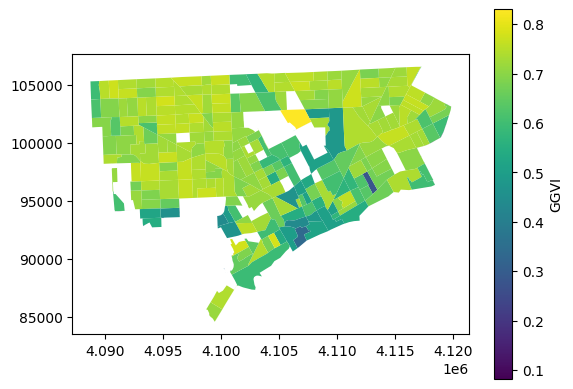

In [23]:
# file path to detroit census tracts shapefile
file_path = Path("data\detroit_shapefile_2024\GGVI_census_tract.shp")

# Read in census tracts shapefile as GeoDataframe and convert column type to integer
census_tracts_df = gpd.read_file(current_dir / file_path)
census_tracts_df['TRACTCE'] =  census_tracts_df['TRACTCE'].astype(int)

# Merge the GGVI score column to the census tracts geodataframe!!!
merged_tracts = census_tracts_df.merge(GGVIs, left_on='TRACTCE', right_on='TRACTCE', how='left') # Join census output dataframe to shapefile dataframe

# plot to check out the result!
merged_tracts.plot(
    column= 'GGVI',
    legend=True,
    legend_kwds={"label": "GGVI", "orientation": "vertical"},
)

# convert geodataframe to shapefile to import into a GIS for more visualization
merged_tracts.to_file("data/outputs/GGVI_DETROIT.shp")